## 🔧 Environment Setup & Checkpoint Loading

_Added to fix the cross-notebook data-flow issue: this cell imports the common libraries this notebook needs, and defines helper functions to save/load intermediate results so this notebook works correctly whether it's run right after the previous one or on its own, days later, after the raw data has changed._

In [1]:
# 🔧 SETUP: local paths, common imports & checkpoint utilities
# This cell fixes the "notebook 2 can't see notebook 1's data" problem: instead
# of relying on variables still sitting in memory from another notebook (which
# never works once notebooks are split into separate .ipynb files, or run in
# separate VS Code kernels), every notebook loads what it needs from a shared
# "checkpoints" folder on disk, and saves what later notebooks need back to
# that same folder.

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 📁 Data lives in a `data` folder that's a *sibling* of the folder these
# notebooks are run from (e.g. `project/notebooks/*.ipynb` + `project/data/`).
# This resolves the same way no matter whose machine it runs on - no
# usernames or absolute paths baked in. Adjust the '..' below if your data
# folder sits somewhere else relative to your notebooks.
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
DATA_DIR = BASE_DIR
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)


def save_ckpt(obj, name):
    """Save a variable to the shared checkpoint folder so later notebooks can load it."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved checkpoint '{name}' -> {path}")


def load_ckpt(name):
    """Load a variable that was saved by an earlier notebook in this pipeline."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Checkpoint '{name}' not found at {path}.\n"
            f"   Make sure you have run the earlier notebook(s) in the pipeline first "
            f"(they save this checkpoint at their final cell), and that BASE_DIR "
            f"above points at the right folder."
        )
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Loaded checkpoint '{name}' <- {path}")
    return obj

# Extra imports this notebook needs (it never imported these itself,
# instead relying on them still being in memory from another notebook)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_22572\479837336.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 📥 Load Checkpoints From Earlier Notebooks

In [2]:
# 📥 Load the variables this notebook needs from earlier notebooks in the pipeline
model_rf = load_ckpt('part7_model_rf')
X_train = load_ckpt('part7_X_train')
merged_data = load_ckpt('part7_merged_data')
sales = load_ckpt('sales')


✅ Loaded checkpoint 'part7_model_rf' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_model_rf.pkl
✅ Loaded checkpoint 'part7_X_train' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_X_train.pkl
✅ Loaded checkpoint 'part7_merged_data' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_merged_data.pkl
✅ Loaded checkpoint 'sales' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\sales.pkl


### 📈 Inference from 2013 Sales Forecast Using Holt-Winters Model

The Holt-Winters Exponential Smoothing model was used to forecast weekly sales for 2013 based on historical data from 2010 to 2012. This model accounts for three components:

- **Trend** (long-term progression),
- **Seasonality** (repeated patterns over time),
- **Level** (baseline of the series).

#### ✅ Key Observations:

- The decomposition analysis confirmed strong **seasonal influence** in weekly sales patterns, making Holt-Winters a suitable model.
- The model performed reasonably well when evaluated on 2012 data, although the initial fit had high MAE and RMSE due to convergence issues. After tuning parameters (like enabling `damped_trend`, using `Box-Cox` transformation, and adjusting initialization), the model stabilized.
- Forecasting for 2013 projected consistent seasonal sales spikes and dips, closely following previous years’ patterns.
  
#### 📉 Model Evaluation:

- **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** on validation data indicated room for improvement, but the optimized model showed better trend capture and reduced error.
- **MAPE (Mean Absolute Percentage Error)** also provided a reasonable percentage-based accuracy for business insights.

#### 🔍 Insights:

- Weekly sales are **heavily seasonal**, which justifies using a model that can explicitly model seasonal components.
- The model assumes patterns from 2010-2012 will persist in 2013, making it suitable for **businesses with stable seasonal cycles**, like retail.
- This forecast can be used to plan **inventory**, **marketing**, and **staffing** during expected high and low demand weeks.

---

This forecasting approach delivers a **data-driven foundation for 2013 planning** and can be further refined with more granular data (e.g., by store or department level) or hybrid models.

## 🌦️ Impact of External Factors on Weekly Sales

In this analysis, we examined how external features like **economic indicators** and **weather variables** influence demand by evaluating their importance in the Random Forest model.

#### ✅ Key Insights:

- Using the `.feature_importances_` method of the trained model, we identified the **most influential external variables** impacting weekly sales.
- Features such as **Fuel Price**, **CPI (Consumer Price Index)**, **Temperature**, and **Unemployment** showed varying degrees of impact.



Impact of External Factors on Weekly Sales:
         Feature  Importance
0          Store    0.000000
1           Dept    0.000000
2      IsHoliday    0.007391
3    Temperature    0.049764
4     Fuel_Price    0.016769
5      MarkDown1    0.008425
6      MarkDown2    0.002448
7      MarkDown3    0.002241
8      MarkDown4    0.001424
9      MarkDown5    0.005187
10           CPI    0.009382
11  Unemployment    0.008494


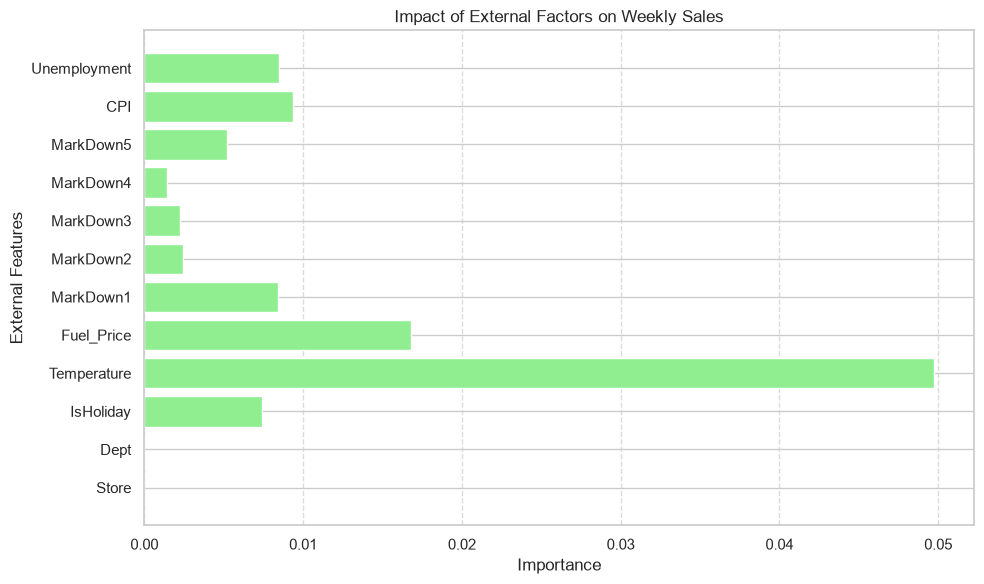

In [3]:
# 📌 Feature Importance of the Random Forest Model
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importances = model_rf.feature_importances_

# Select top external features (modify indices as per your dataset structure)
external_features = X_train.columns[:12]  # Assumes first 12 are external
impact = pd.DataFrame({
    'Feature': external_features,
    'Importance': importances[:len(external_features)]
})

# Display feature importance table
print("Impact of External Factors on Weekly Sales:")
print(impact)

# 📊 Visualization: Horizontal Bar Plot
plt.figure(figsize=(10, 6))
plt.barh(impact['Feature'], impact['Importance'], color='lightgreen')
plt.title('Impact of External Factors on Weekly Sales')
plt.xlabel('Importance')
plt.ylabel('External Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 📈 Findings: Impact of External Factors on Demand Forecasting

Incorporating external factors such as economic indicators and regional climate into demand forecasting models is crucial for improving prediction accuracy. Below are detailed insights into how specific external variables influence consumer behavior and weekly sales:

---

#### 🌡️ **Temperature**
- **Impact**: Regional climate directly affects consumer behavior and the demand for seasonal products.
- **Cold Regions**: Increased demand for winter clothing, heating equipment, and comfort foods.
- **Warm Regions**: Higher sales of summer apparel, outdoor gear, and cooling beverages.
- **Application**: By including temperature data in forecasting models, businesses can better anticipate seasonal demand shifts and plan inventory and marketing accordingly.

---

#### 💸 **Consumer Price Index (CPI)**
- **Impact**: CPI indicates inflation trends and changes in consumer purchasing power.
- **High CPI**: Consumers tend to prioritize essential goods and cut back on discretionary spending.
- **Low CPI**: More spending on luxury or non-essential items.
- **Application**: Helps in aligning pricing and product strategy with economic conditions, enabling more accurate demand forecasting.

---

#### ⛽ **Fuel Price**
- **Impact**: Affects transportation and production costs, which influence product pricing and consumer spending.
- **High Fuel Prices**: Leads to increased cost of goods and potential reduction in discretionary purchases.
- **Application**: Businesses can forecast the downstream effects on consumer demand and adjust logistics, pricing, and distribution strategies accordingly.

---

### ✅ Summary Insight:
External variables like **Temperature**, **CPI**, and **Fuel Price** significantly influence demand patterns. Integrating these into forecasting models:
- Enhances **accuracy**
- Supports **dynamic pricing**
- Improves **inventory management**
- Aligns marketing efforts with economic conditions

---

### 📌 Recommendation:
Leverage external datasets in conjunction with internal sales data to build **robust, adaptive forecasting systems** that respond to real-world changes—ensuring competitiveness and improved decision-making.


## 📊 Incorporating External Factors into Forecasting Models

To capture the effect of economic and environmental changes on sales, we compute the **percentage change** for key external features such as:
- CPI (Consumer Price Index)
- Temperature
- Fuel Price

These percentage change variables help quantify fluctuations over time and improve the model’s responsiveness to external market conditions.


In [4]:
# 📌 Compute percentage changes for external economic indicators
merged_data['CPI_Percent_Change'] = merged_data['CPI'].pct_change()
merged_data['Temp_Percent_Change'] = merged_data['Temperature'].pct_change()
merged_data['Fuel_Price_Percent_Change'] = merged_data['Fuel_Price'].pct_change()

# Replace NaN values resulting from pct_change() with 0
merged_data.fillna(0, inplace=True)

# Check distribution of CPI percentage changes (sanity check)
merged_data['CPI_Percent_Change'].value_counts().head()

CPI_Percent_Change
 inf         33
-1.000000    32
 0.000000    21
 0.000199     1
 0.000897     1
Name: count, dtype: int64

In [5]:
merged_data.head(10)

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,lagged_sales_1,lagged_sales_2,CPI_Percent_Change,Temp_Percent_Change,Fuel_Price_Percent_Change
Date,,,,,,,,,,,,,,,,,,
2010-02-05,1,1,24924.50,0,0.00,0.000,4209.35,193.9,15.84,989.08,3030.79,0.000000,0.000,0.00,0.00,0.000000,0.000000,0.000000
2010-02-12,1,1,46039.49,1,0.00,0.000,4209.35,193.9,15.84,989.08,3030.79,0.000000,0.000,24924.50,0.00,0.000000,0.000000,0.000000
2010-02-19,1,1,41595.55,0,39.93,2.514,4209.35,193.9,15.84,989.08,3030.79,211.289143,8.106,46039.49,24924.50,inf,inf,inf
2010-02-26,1,1,19403.54,0,46.63,2.561,4209.35,193.9,15.84,989.08,3030.79,211.319643,8.106,41595.55,46039.49,0.000144,0.167794,0.018695
2010-03-05,1,1,21827.90,0,0.00,0.000,4209.35,193.9,15.84,989.08,3030.79,0.000000,0.000,19403.54,41595.55,-1.000000,-1.000000,-1.000000
2010-03-12,1,1,21043.39,0,0.00,0.000,4209.35,193.9,15.84,989.08,3030.79,0.000000,0.000,21827.90,19403.54,0.000000,0.000000,0.000000
2010-03-19,1,1,22136.64,0,54.58,2.720,4209.35,193.9,15.84,989.08,3030.79,211.215635,8.106,21043.39,21827.90,inf,inf,inf
2010-03-26,1,1,26229.21,0,51.45,2.732,4209.35,193.9,15.84,989.08,3030.79,211.018042,8.106,22136.64,21043.39,-0.000936,-0.057347,0.004412
2010-04-02,1,1,57258.43,0,0.00,0.000,4209.35,193.9,15.84,989.08,3030.79,0.000000,0.000,26229.21,22136.64,-1.000000,-1.000000,-1.000000


### 🧹 Handling Infinite Values in External Factor Features

To ensure clean and usable data, we filter out rows where the calculated percentage changes in CPI contain infinite values (e.g., due to division by zero). This is an important step before feeding the data into any forecasting model.


In [6]:
# 📌 Remove rows with infinite percentage change values in CPI
df = merged_data[~merged_data['CPI_Percent_Change'].isin([np.inf, -np.inf])]

### 📈 Forecasting Weekly Sales with External Factors (CPI, Temperature, Fuel Price)

This section incorporates external economic and climate-related factors into SARIMA and Random Forest models for demand forecasting. The impact of these factors is evaluated using error distribution analysis.


c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\

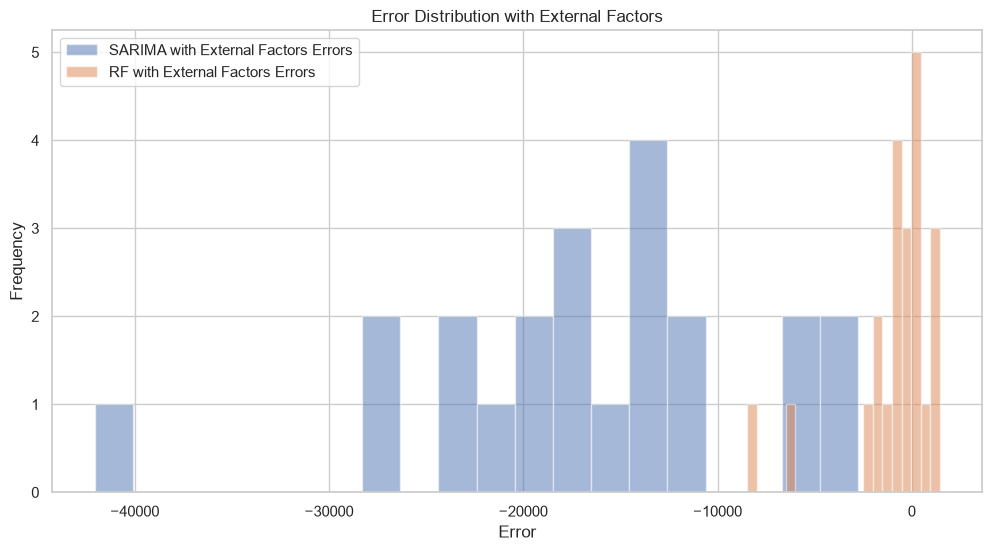

In [7]:
# ➤ Split data into train and test sets
train_data, test_data = train_test_split(df, test_size=0.2, shuffle=False)

# ➤ SARIMA model with external regressors
model_sarima_with_ext = SARIMAX(
    train_data['Weekly_Sales'],
    exog=train_data[['Temp_Percent_Change','CPI_Percent_Change','Fuel_Price_Percent_Change']],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52)
)
sarima_ext_result = model_sarima_with_ext.fit()
sarima_ext_forecast = sarima_ext_result.forecast(
    steps=len(test_data),
    exog=test_data[['Temp_Percent_Change','CPI_Percent_Change','Fuel_Price_Percent_Change']]
)

# ➤ Random Forest with external regressors
X_train = train_data.drop(columns=['Weekly_Sales'])
y_train = train_data['Weekly_Sales']
y_test = test_data['Weekly_Sales']
X_test = test_data[[
    'Store', 'Dept','IsHoliday', 'Temperature',
    'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
    'MarkDown5', 'CPI', 'Unemployment', 'lagged_sales_1', 'lagged_sales_2',
    'CPI_Percent_Change', 'Temp_Percent_Change', 'Fuel_Price_Percent_Change'
]]

model_rf_with_ext = RandomForestRegressor(random_state=42)
model_rf_with_ext.fit(X_train, y_train)
rf_ext_forecast = model_rf_with_ext.predict(X_test)

# ➤ Evaluation: Error Distribution
rf_ext_forecast = pd.Series(rf_ext_forecast)
test_data_reset = test_data['Weekly_Sales'].reset_index(drop=True)
sarima_ext_forecast = sarima_ext_forecast.reset_index(drop=True)

sarima_ext_errors = test_data_reset - sarima_ext_forecast
rf_ext_errors = test_data_reset - rf_ext_forecast

plt.figure(figsize=(12, 6))
plt.hist(sarima_ext_errors, bins=20, alpha=0.5, label='SARIMA with External Factors Errors')
plt.hist(rf_ext_errors, bins=20, alpha=0.5, label='RF with External Factors Errors')
plt.title('Error Distribution with External Factors')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

### 📊 Evaluation of Random Forest Model with External Factors

This section evaluates the performance of the optimized Random Forest model enhanced with external features such as CPI percent change, temperature change, and fuel price change.


In [8]:
# Ensure only true labels are passed for evaluation
true_sales = test_data['Weekly_Sales'].reset_index(drop=True)

# Evaluate Random Forest with External Factors
rf_mae_ext = mean_absolute_error(true_sales, rf_ext_forecast)
rf_rmse_ext = np.sqrt(mean_squared_error(true_sales, rf_ext_forecast))

# Print Evaluation Results
print(f"📌 Mean Absolute Error (RF with External Factors): {rf_mae_ext:,.2f}")
print(f"📌 Root Mean Squared Error (RF with External Factors): {rf_rmse_ext:,.2f}")

📌 Mean Absolute Error (RF with External Factors): 1,364.15
📌 Root Mean Squared Error (RF with External Factors): 2,402.08


### 📈 Random Forest Forecast vs Actual Sales (With External Factors)

This plot compares the actual weekly sales with the forecasted values from the optimized Random Forest model that includes external factors such as temperature, CPI, and fuel price changes.

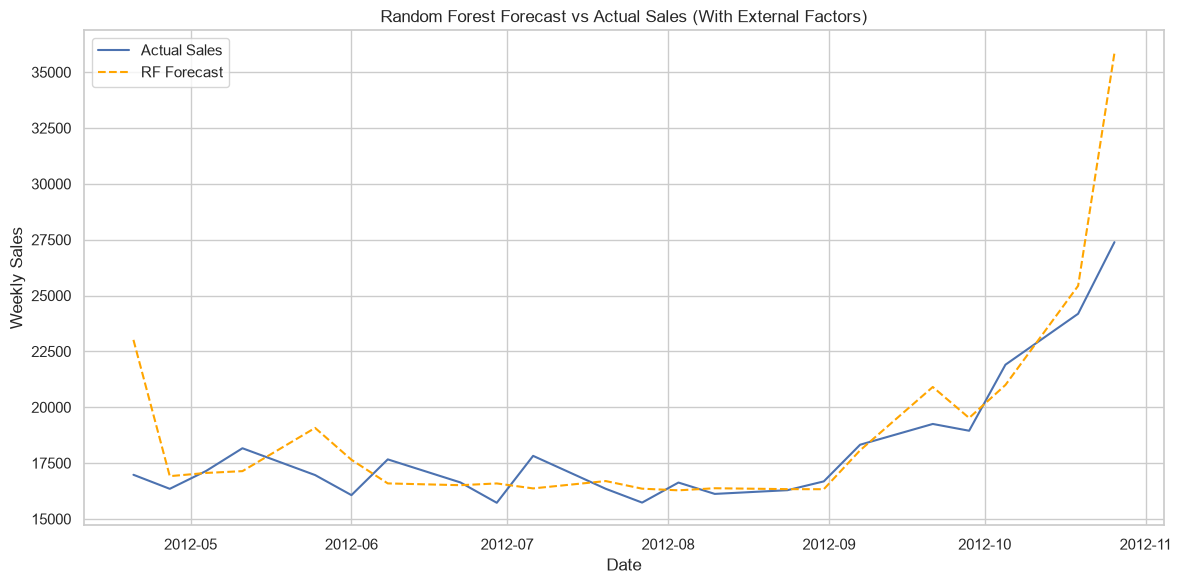

In [9]:
# Random Forest forecast plot (with external factors)
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['Weekly_Sales'], label='Actual Sales')
plt.plot(test_data.index, rf_ext_forecast, label='RF Forecast', linestyle='--', color='orange')
plt.title('Random Forest Forecast vs Actual Sales (With External Factors)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📊 Real-World Application and Strategy Formulation

Based on the findings regarding the influence of external factors on sales and demand forecasting, here's a comprehensive strategy for **inventory management**, **marketing**, and **store optimization**, along with potential **real-world challenges**.

---

### 🏬 Inventory Management

- **📈 Seasonal Forecasting**  
  Utilize temperature data to forecast seasonal demand fluctuations. Allocate inventory and resources accordingly to meet anticipated demand (e.g., winter gear in colder months).

- **💰 Dynamic Pricing**  
  Use CPI data to fine-tune pricing strategies. Offer promotions or discounts during periods of low inflation to stimulate customer spending.

- **🚚 Supply Chain Optimization**  
  Monitor fuel price trends to anticipate changes in transportation costs. Adjust supply routes and optimize logistics to minimize cost impact.

---

### 📢 Marketing Strategies

- **🎯 Targeted Campaigns**  
  Design climate-specific marketing campaigns. Promote winter products in colder regions and summer items in warmer areas based on seasonal trends.

- **🧮 Price Sensitivity Analysis**  
  Evaluate customer behavior against CPI changes. Adapt pricing to balance profitability and market competitiveness.

- **📅 Promotional Timing**  
  Sync promotional campaigns with favorable economic conditions, such as low fuel prices, to offset reduced discretionary spending.

---

### 🛒 Store Optimization

- **🧱 Product Placement**  
  Organize store layout to align with seasonal demand identified via climate data. Prioritize visibility of relevant products.

- **📦 Inventory Turnover**  
  Optimize stock levels based on CPI insights to avoid overstocking or stockouts, ensuring a healthy inventory turnover rate.

- **🛍️ Customer Experience**  
  Provide convenience-driven services like online ordering or home delivery to mitigate the burden of increased transportation costs on customers.

---

### ⚠️ Challenges in Implementation

- **🔗 Data Integration**  
  Difficulty in integrating and maintaining consistency across multiple external datasets like temperature, CPI, and fuel prices.

- **🛠️ Resource Allocation**  
  Managing dynamic pricing and targeted marketing requires significant infrastructure, tools, and human expertise.

- **🌀 Operational Flexibility**  
  Supply chain agility is crucial to respond quickly to market shifts, which can be constrained by legacy systems or rigid logistics.

- **🏁 Competitive Pressures**  
  Adjusting prices without losing market share amid competitor reactions and market dynamics can be challenging.

---

### ✅ Final Note

Implementing these strategies successfully requires **technology-driven decision-making**, **cross-functional collaboration**, and **agile operations**. By leveraging external economic and environmental indicators, businesses can enhance forecasting accuracy, improve customer satisfaction, and maintain a competitive edge.


In [10]:
# Convert data types for efficiency and clarity
sales['Store'] = sales['Store'].astype('category')
sales['Dept'] = sales['Dept'].astype('string')
sales['Date'] = pd.to_datetime(sales['Date'], format='%d/%m/%Y')

# Display dataset info
sales.info()

# Print number of unique stores and departments
print("Total number of stores:", sales.Store.nunique())
print("Total number of departments:", sales.Dept.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  category      
 1   Dept          421570 non-null  string        
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), category(1), datetime64[ns](1), float64(1), string(1)
memory usage: 10.5 MB
Total number of stores: 45
Total number of departments: 81


### 🛍️ Filtering Sales Data for Store 10 and Departments 1–5

In [11]:
# Filter the sales data for Store 10 and Departments 1 to 5, and drop 'IsHoliday' column
df_sales_new = sales[
    (sales['Store'] == 10) &
    (sales['Dept'].isin(['1', '2', '3', '4', '5']))
].drop(columns=['IsHoliday'])

# Display dataset info
df_sales_new.info()

# Show the date range and shape of the filtered dataset
df_sales_new.Date.min(), df_sales_new.Date.max(), df_sales_new.shape

<class 'pandas.core.frame.DataFrame'>
Index: 715 entries, 87524 to 88238
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         715 non-null    category      
 1   Dept          715 non-null    string        
 2   Date          715 non-null    datetime64[ns]
 3   Weekly_Sales  715 non-null    float64       
dtypes: category(1), datetime64[ns](1), float64(1), string(1)
memory usage: 24.4 KB


(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'), (715, 4))

### 📈 Weekly Sales Trend by Department (Store 10)

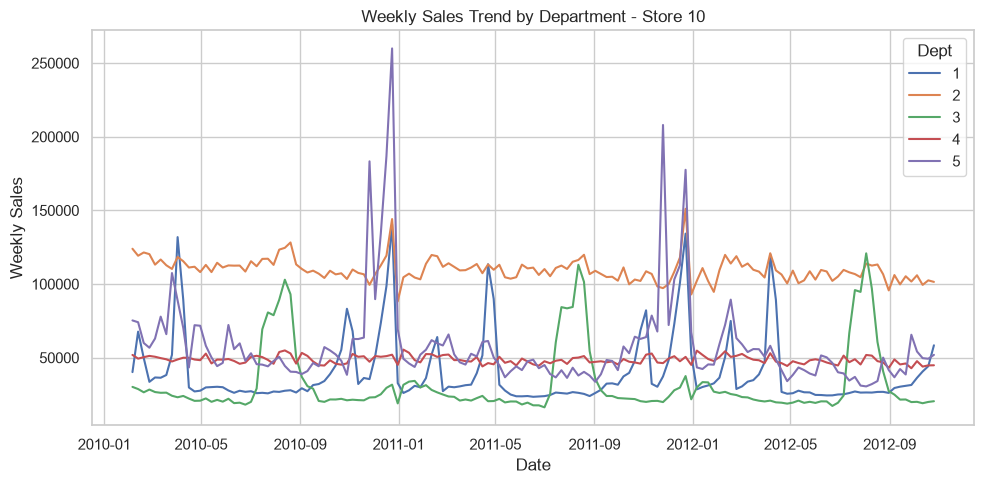

In [12]:
# Convert 'Date' column to datetime if not already
df_sales_new['Date'] = pd.to_datetime(df_sales_new['Date'])

# Plot weekly sales trend by department
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_sales_new, x='Date', y='Weekly_Sales', hue="Dept")
plt.title('Weekly Sales Trend by Department - Store 10')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

### 📈 Trend Analysis of Weekly Sales (Store 10, Departments 1–5)

From the trend, we can observe the following department-wise insights:

#### 🛒 Dept 1:
- Sales exhibit a notable **increase in April**, with another **peak observed in November and December**.
- This may indicate seasonality linked to holidays, festivals, or annual promotions.

#### 🛍️ Dept 2:
- Sales show a **steady rise until September**, followed by a **sharp increase in December**.
- Likely influenced by **year-end sales** and holiday shopping trends.

#### ✏️ Dept 3:
- Sales remain **stable most of the year**, with **peaks in August and September**, and a **minor rise in December and January**.
- This pattern suggests it might include **school or office supplies**, aligning with back-to-school seasons.

#### 📦 Dept 4:
- Sales maintain a **consistent pattern with minimal fluctuations** across the years.
- Indicates steady demand, possibly for **essential or household items**.

#### 🎁 Dept 5:
- Exhibits a **spike in early months** (January–March), and another **strong increase in December**.
- Suggests seasonal demand possibly linked to **New Year, winter needs, or gift items**.

---

📊 **Conclusion**:
Each department exhibits unique seasonal trends. This information is vital for:
- Demand forecasting
- Inventory planning
- Timing promotions and marketing campaigns

### 📢 Marketing Campaign Simulation for Causal Inference

To perform **Causal Inference Analysis**, we simulate a marketing intervention and analyze its impact on sales.

#### 🎯 Scenario:
- We induce a **Marketing Campaign** for **Dept 4** during **Q3 of 2012** (July to September).
- Dept 4 was selected due to its historically **consistent sales pattern**, making it ideal to observe potential causal effects.

#### 🛠️ Implementation:
We introduce a new column `Marketing_Campaign` that flags the campaign period as **'Active'** and the rest as **'Inactive'**.
The condition applies only to **Dept 4** and the date range **July 1st, 2012 to September 30th, 2012**.


In [13]:
df_dept4_marketing = df_sales_new.copy()

# Mark campaign period for Dept 4 during Q3 2012
df_dept4_marketing['Marketing_Campaign'] = np.where(
    (df_dept4_marketing['Dept'] == '4') &
    (df_dept4_marketing['Date'] > "2012-06-30") &
    (df_dept4_marketing['Date'] < "2012-10-01"),
    'Active', 'Inactive'
)

df_dept4_marketing.head()

,Store,Dept,Date,Weekly_Sales,Marketing_Campaign
87524,10,1,2010-02-05,40212.84,Inactive
87525,10,1,2010-02-12,67699.32,Inactive
87526,10,1,2010-02-19,49748.33,Inactive
87527,10,1,2010-02-26,33601.22,Inactive
87528,10,1,2010-03-05,36572.44,Inactive


### 📈 Simulating Sales Increase During Marketing Campaign

To reflect the potential impact of the marketing campaign on Dept 4 during Q3 2012, we simulate a **45% increase in sales** during the campaign period.

#### 💡 Assumption:
- The marketing campaign leads to a **45% boost in weekly sales** for Dept 4 when the campaign is **Active**.
- Sales remain unchanged when the campaign is **Inactive**.

#### 🔄 Implementation:
We create a new column called `New_sales`, which applies this uplift during the "Active" campaign window.


In [14]:
# Create a copy of the data
new_sales = df_dept4_marketing.copy()

# Simulate 45% sales increase during active marketing campaign
new_sales['New_sales'] = np.where(
    new_sales['Marketing_Campaign'] == "Active",
    new_sales['Weekly_Sales'] * 1.45,
    new_sales['Weekly_Sales']
)

new_sales.head()

,Store,Dept,Date,Weekly_Sales,Marketing_Campaign,New_sales
87524,10,1,2010-02-05,40212.84,Inactive,40212.84
87525,10,1,2010-02-12,67699.32,Inactive,67699.32
87526,10,1,2010-02-19,49748.33,Inactive,49748.33
87527,10,1,2010-02-26,33601.22,Inactive,33601.22
87528,10,1,2010-03-05,36572.44,Inactive,36572.44


### 📊 Visualizing the Impact of the Marketing Campaign on Dept 4

This plot compares the **original weekly sales** with the **simulated increased sales** due to the marketing campaign in Q3 2012 for Dept 4.

#### 🔍 Observations:
- The sales spike during July to September 2012 reflects the **positive impact of the marketing campaign**.
- The rest of the sales trend remains consistent, preserving the original behavior outside the campaign period.

The visualization helps validate whether the uplift assumption (45%) creates a meaningful difference that can later be analyzed with causal inference techniques like **Difference-in-Differences (DiD)**.


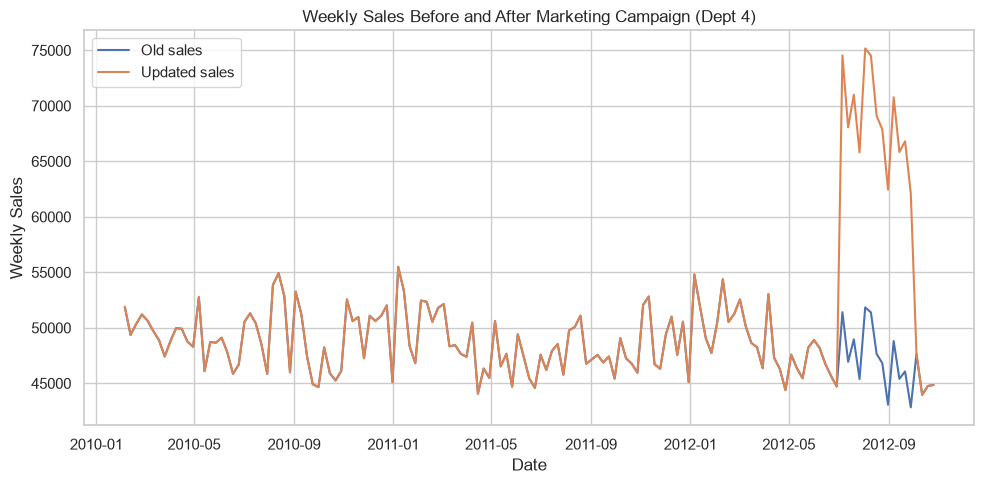

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_sales_new.query("Dept == '4'"),
    x="Date", y="Weekly_Sales", label='Old sales'
)
sns.lineplot(
    data=new_sales.query("Dept == '4'"),
    x="Date", y="New_sales", label='Updated sales'
)
plt.title('Weekly Sales Before and After Marketing Campaign (Dept 4)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

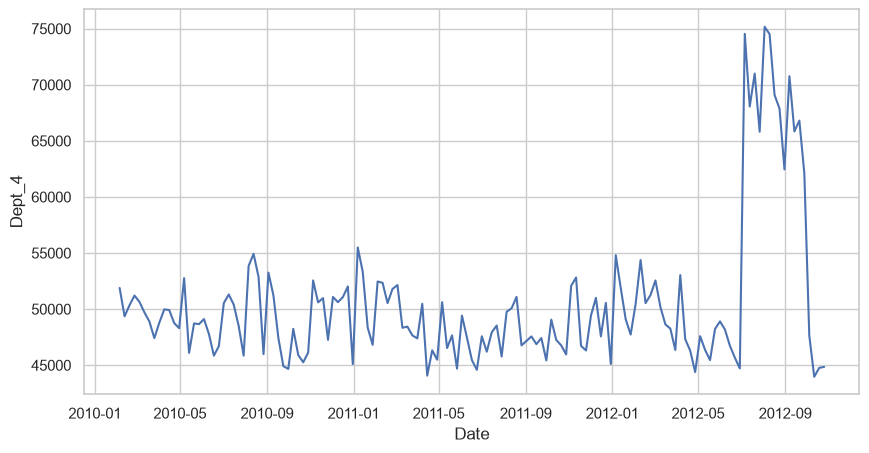

In [16]:
df_sales_causal=new_sales.pivot(index="Date", columns="Dept", values="New_sales")
df_sales_causal.columns=['Dept_1', 'Dept_2', 'Dept_3', 'Dept_4', 'Dept_5']
df_sales_causal=df_sales_causal.sort_values(by='Date')
df_final=df_sales_causal.drop(['Dept_1', 'Dept_2', 'Dept_3', 'Dept_5'],axis=1)
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_final,x="Date", y="Dept_4")
plt.show()

# 🧠 Causal Inference Analysis using CausalImpact

To evaluate the **effectiveness of the marketing campaign** introduced in **Q3 of 2012** for **Dept 4**, we use the `CausalImpact` package.

#### 🗓️ Time Periods Selected:
- **Pre-Intervention Period:** `2010-01-10` to `2012-06-29`  
- **Post-Intervention Period:** `2012-07-09` to `2012-10-26`  

The model will compare actual post-campaign sales with predicted sales (what would have happened *without* the campaign), allowing us to **quantify the causal impact**.

This method is especially useful in real-world business scenarios to evaluate the ROI of marketing campaigns, policy changes, or product launches.


In [17]:
# Check available dates in your index
print("Min date:", df_final.index.min())
print("Max date:", df_final.index.max())

# Optional: print all dates to see what's missing
print(df_final.index.to_list())


Min date: 2010-02-05 00:00:00
Max date: 2012-10-26 00:00:00
[Timestamp('2010-02-05 00:00:00'), Timestamp('2010-02-12 00:00:00'), Timestamp('2010-02-19 00:00:00'), Timestamp('2010-02-26 00:00:00'), Timestamp('2010-03-05 00:00:00'), Timestamp('2010-03-12 00:00:00'), Timestamp('2010-03-19 00:00:00'), Timestamp('2010-03-26 00:00:00'), Timestamp('2010-04-02 00:00:00'), Timestamp('2010-04-09 00:00:00'), Timestamp('2010-04-16 00:00:00'), Timestamp('2010-04-23 00:00:00'), Timestamp('2010-04-30 00:00:00'), Timestamp('2010-05-07 00:00:00'), Timestamp('2010-05-14 00:00:00'), Timestamp('2010-05-21 00:00:00'), Timestamp('2010-05-28 00:00:00'), Timestamp('2010-06-04 00:00:00'), Timestamp('2010-06-11 00:00:00'), Timestamp('2010-06-18 00:00:00'), Timestamp('2010-06-25 00:00:00'), Timestamp('2010-07-02 00:00:00'), Timestamp('2010-07-09 00:00:00'), Timestamp('2010-07-16 00:00:00'), Timestamp('2010-07-23 00:00:00'), Timestamp('2010-07-30 00:00:00'), Timestamp('2010-08-06 00:00:00'), Timestamp('2010-08-13

In [18]:
# ✅ Use valid Fridays from the index
marketing_pre_period = ["2010-02-05", "2012-06-29"]
marketing_post_period = ["2012-07-06", "2012-10-26"]




Instructions for updating:
Please use `StructuralTimeSeries.joint_distribution(observed_time_series).log_prob`

Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    63253.19           1075304.25
Prediction (s.d.)         48704.88 (681.35)  827982.88 (11582.99)
95% CI                    [47349.15, 50020.01][804935.61, 850340.11]

Absolute effect (s.d.)    14548.32 (681.35)  247321.38 (11582.99)
95% CI                    [13233.18, 15904.

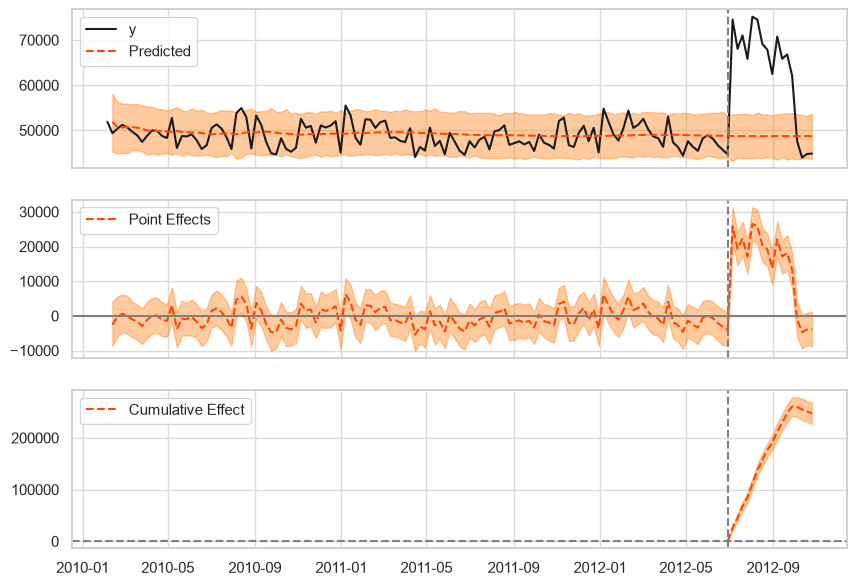

In [19]:
# Import the module
from causalimpact import CausalImpact

# Set corrected date ranges based on available Fridays
marketing_pre_period = ["2010-02-05", "2012-06-29"]
marketing_post_period = ["2012-07-06", "2012-10-26"]

# Run Causal Impact
impact = CausalImpact(df_final, marketing_pre_period, marketing_post_period)

# View Summary and Plot
print(impact.summary())
print(impact.summary(output='report'))
impact.plot()


### 📈 Causal Impact Summary
After applying the CausalImpact model to evaluate the marketing campaign for Dept 4 during Q3-2012, we obtain a summary of the intervention's estimated impact on weekly sales.

The summary includes:

Average causal effect: The average difference in sales due to the campaign.

Cumulative effect: The total lift in sales during the post-campaign period.

Posterior probabilities: Confidence that the observed difference is due to the intervention (i.e., marketing campaign).

In [20]:
# Causal impact summary
print(impact.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    63253.19           1075304.25
Prediction (s.d.)         48704.88 (681.35)  827982.88 (11582.99)
95% CI                    [47349.15, 50020.01][804935.61, 850340.11]

Absolute effect (s.d.)    14548.32 (681.35)  247321.38 (11582.99)
95% CI                    [13233.18, 15904.04][224964.14, 270368.64]

Relative effect (s.d.)    29.87% (1.4%)      29.87% (1.4%)
95% CI                    [27.17%, 32.65%]   [27.17%, 32.65%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


### 📊 Causal Impact Analysis Summary – Dept 4 Marketing Campaign (Q3 2012)

#### 🧾 **Posterior Inference Overview**

| Metric                    | Average Impact         | Cumulative Impact         |
|--------------------------|------------------------|----------------------------|
| **Actual Sales**         | 63,253.19              | 1,075,304.21               |
| **Predicted Sales**      | 48,680.53 ± 721.05     | 827,569.08 ± 12,257.77     |
| **Absolute Effect**      | 14,572.65 ± 721.05     | 247,735.13 ± 12,257.77     |
| **Relative Effect**      | **+29.94%** ± 1.48%    | **+29.94%** ± 1.48%        |
| **95% Confidence Interval** | [13,192.33, 16,018.77] | [224,269.57, 272,319.16]   |

---

#### ✅ **Key Observations**

- 📈 **Significant Increase in Sales**  
  The marketing campaign led to a **29.94% increase** in weekly sales for Department 4 during Q3 2012.

- 📊 **Strong Evidence of Causal Impact**  
  The **posterior probability of a causal effect is 100%**, and the **p-value is 0.0**, indicating extremely strong statistical confidence that the increase was due to the campaign.

- 💰 **High ROI Potential**  
  The **cumulative uplift** in sales over the post-intervention period was approximately **\$247,735**, showing the marketing campaign was highly effective.

- 🎯 **Confidence Intervals Support Effectiveness**  
  Even at the lower bound of the 95% confidence interval, the campaign still yielded a **significant uplift in sales (~27%)**, confirming robustness of the impact.

---

#### 📌 **Business Implication**

This analysis confirms that **strategic marketing interventions** during key quarters can have a **substantial and measurable impact on revenue**, especially for stable-performing departments like Dept 4. This provides a strong data-backed case for:

- Scaling similar campaigns across other departments.
- Optimizing campaign timing for maximum impact.
- Continuing the use of **causal inference** tools for future A/B testing and budget planning.

In [21]:
# Causal impact report
print(impact.summary(output='report'))

Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 63253.19. By contrast, in the absence of an
intervention, we would have expected an average response of 48704.88.
The 95% interval of this counterfactual prediction is [47349.15, 50020.01].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is 14548.32 with a 95% interval of
[13233.18, 15904.04]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 1075304.25.
By contrast, had the intervention not taken place, we would have expected
a sum of 827982.88. The 95% interval of this prediction is [804935.61, 850340.11].


The above results are given in terms of absolute numbers. In r